In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from geomstats.learning.mds import MDS
from geomstats.geometry.matrices import Matrices

from geomstats.geometry.hermitian import Hermitian


pitchfork bifurcation:
$$\dot{x} = \mu*x - x^2$$

* $\mu < 0$ one stable at origin
* $\mu = 0$ critical point
* $\mu > 0$ two fixed points (two stable at $\pm\sqrt{\mu}$, one unstable origin)

observable:
$$ y(x) = [x, x^2, x^3]$$

Forward step with Euler:
$$ x_{k+1} = x_k + \Delta t * \dot{x}$$

In [ ]:
def simulate_pitchfork(mu, x0=0.1, dt=0.01, T=500):
    x = np.zeros(T)
    x[0] = x0

    for k in range(T - 1):
        x[k + 1] = x[k] + dt * (mu * x[k] - x[k] ** 3)

    return x


def observable(x):
    g = np.vstack([x, x**2, x**3])
    return g

In [ ]:
# Parameters
dt = 0.01
T = 400
x0 = 0.1

# Three regimes
g_pre = observable(simulate_pitchfork(mu=-0.5, x0=x0, dt=dt, T=T))
g_crit = observable(simulate_pitchfork(mu=0.0, x0=x0, dt=dt, T=T))
g_post = observable(simulate_pitchfork(mu=0.5, x0=x0, dt=dt, T=T))

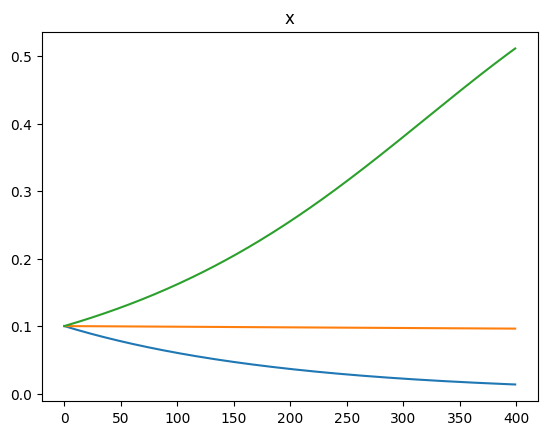

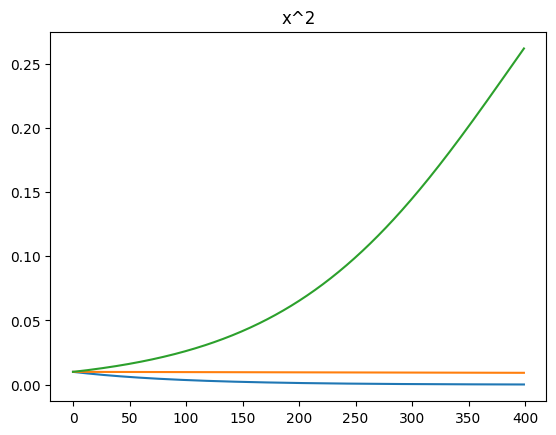

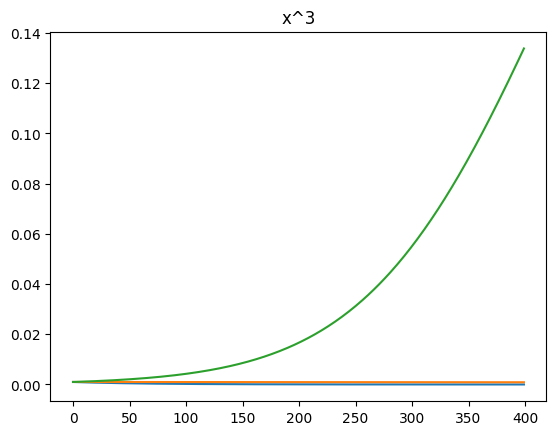

In [ ]:
plt.plot(g_pre[0, :])
plt.plot(g_crit[0, :])
plt.plot(g_post[0, :])
plt.title("x")
plt.show()

plt.plot(g_pre[1, :])
plt.plot(g_crit[1, :])
plt.plot(g_post[1, :])
plt.title("x^2")
plt.show()

plt.plot(g_pre[2, :])
plt.plot(g_crit[2, :])
plt.plot(g_post[2, :])
plt.title("x^3")
plt.show()

In [ ]:
def compute_dmd(Y, r=None):
    X = Y[:, :-1]
    X_next = Y[:, 1:]

    # SVD
    U, S, Vh = np.linalg.svd(X, full_matrices=False)

    if r is not None:
        U = U[:, :r]
        S = S[:r]
        Vh = Vh[:r, :]

    # Reduced operator
    A_tilde = U.T @ X_next @ Vh.T @ np.diag(1 / S)

    # Eigen decomposition
    eigvals, W = np.linalg.eig(A_tilde)
    modes = X_next @ Vh.T @ np.diag(1 / S) @ W

    return A_tilde, eigvals, modes


dmd_pre, eig_pre, _ = compute_dmd(g_pre)
dmd_crit, eig_crit, _ = compute_dmd(g_crit)
dmd_post, eig_post, _ = compute_dmd(g_post)

In [ ]:
mus = [-0.5, -0.1, -0.05, 0.0, 0.05, 0.1, 0.5]

# eigs = [compute_dmd(observable(simulate_pitchfork(mu=mu, x0=x0, dt=dt, T=T)))[1] for mu in mus]

for mu in mus:
    X = simulate_pitchfork(mu)
    Y = observable(X)
    Y = Y[:, 200:]
    dmd, eigvals, modes = compute_dmd(Y, r=3)

    print(f"\nmu = {mu}")
    print(dmd)
    print("DMD eigenvalues:")
    print(eigvals)


mu = -0.5
[[ 9.94989827e-01 -5.99956704e-04  1.00216301e-02]
 [-1.26202298e-04  9.89993286e-01  1.36803141e-03]
 [ 9.65530247e-07  2.34493180e-04  9.85045805e-01]]
DMD eigenvalues:
[0.99500002 0.99005401 0.98497489]

mu = 0.0
[[ 9.99905594e-01 -1.94402758e-03  1.03458822e-02]
 [-9.12753819e-06  9.99623411e-01  5.04603352e-03]
 [ 1.87454500e-10  1.75179812e-05  9.99348874e-01]]
DMD eigenvalues:
[0.99997669 0.99975287 0.99914832]

mu = 0.5
[[ 1.00304490e+00 -9.23154897e-03  2.75643462e-02]
 [ 1.13643180e-03  1.00200060e+00  3.78342281e-02]
 [-3.57493233e-05 -1.24137756e-03  9.99503232e-01]]
DMD eigenvalues:
[1.00193687+0.j         1.00130593+0.00743397j 1.00130593-0.00743397j]


In [77]:
dmd_space = Matrices(dmd_pre.shape[0], dmd_pre.shape[1])
eig_space = Hermitian(dmd_pre.shape[0])

In [ ]:
# ALIGN EVERYTHING TO PRE

aligned_dmd_crit = Matrices.align_matrices(dmd_crit, dmd_pre)
aligned_dmd_post = Matrices.align_matrices(dmd_post, dmd_pre)


In [ ]:
ts = [0.2, 0.4, 0.5, 0.6, 0.8]
geodesic_dmds = dmd_space.metric.geodesic(dmd_pre, aligned_dmd_post)(ts)

geodesic_dmds_to_crit = dmd_space.metric.geodesic(dmd_pre, aligned_dmd_crit)(ts)

In [ ]:
# eig_pre = np.array(sorted(eig_pre))
# eig_crit = np.array(sorted(eig_crit))
# eig_post = np.array(sorted(eig_post))

mus = list((i * 0.05) - 0.5 for i in range(20))
eigs = [
    np.array(
        sorted(compute_dmd(observable(simulate_pitchfork(mu=mu, x0=x0, dt=dt, T=T)))[1])
    )
    for mu in mus
]

ts = list(x * 0.05 for x in range(20))
geodesic_eigs = [
    np.array(sorted(x)) for x in eig_space.metric.geodesic(eigs[0], eigs[-1])(ts)
]

print(eig_pre)
print(geodesic_eigs[0])
print(eig_crit)
print(eig_post)


[0.98441096 0.99019013 0.99500085]
[0.98441096+0.j 0.99019013+0.j 0.99500085+0.j]
[0.99912323 0.99974564 0.99997601]
[1.00389287+0.j         1.00592301-0.00634121j 1.00592301+0.00634121j]


[[ 0.01467266 -0.00078921]
 [ 0.0128969  -0.00028394]
 [ 0.01112283  0.00021979]
 [ 0.00935142  0.00072145]
 [ 0.00758395  0.00122044]
 [ 0.00582214  0.0017162 ]
 [ 0.00406828  0.00220839]
 [ 0.00232531  0.00269747]
 [ 0.00059676  0.00318628]
 [-0.00111495  0.00368673]
 [-0.00283335  0.00428815]
 [-0.00466313  0.00380717]
 [-0.00617602  0.00316221]
 [-0.00762704  0.00256321]
 [-0.00900685  0.00193883]
 [-0.01028791  0.00125479]
 [-0.01143386  0.00049473]
 [-0.01240547 -0.0003396 ]
 [-0.01316865 -0.00122781]
 [-0.013708   -0.00212856]
 [ 0.01467266 -0.00078921]
 [ 0.0132542  -0.00085503]
 [ 0.01183576 -0.00092086]
 [ 0.01041732 -0.00098671]
 [ 0.00899889 -0.00105257]
 [ 0.00758048 -0.00111845]
 [ 0.00616209 -0.00118433]
 [ 0.00474373 -0.00125022]
 [ 0.00332543 -0.00131614]
 [ 0.00190721 -0.00138209]
 [ 0.0004891  -0.00144813]
 [-0.00092887 -0.00151431]
 [-0.00234666 -0.00158072]
 [-0.00376421 -0.00164748]
 [-0.00518144 -0.00171489]
 [-0.00659841 -0.00178356]
 [-0.00801551 -0.00185413]
 

/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_63991/3488134460.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes.scatter(
/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_63991/3488134460.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes.scatter(


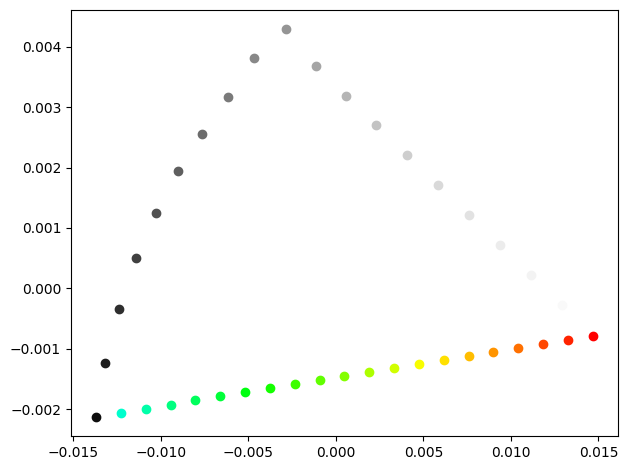

In [130]:
eig_mds = MDS(eig_space)
eigs_in_2d = eig_mds.fit(list(eigs) + list(geodesic_eigs)).embedding_
labs = [str(mu) + "mu" for mu in mus] + [
    str(t) for t in ts
]  # + [str(t)+"crit" for t in ts]
print(eigs_in_2d)
cmap = plt.get_cmap("hsv")
muscmap = plt.get_cmap("Greys")
fig, axes = plt.subplots(1, 1)
for mat in range(eigs_in_2d.shape[0]):
    print(mat)
    print(mat / len(eigs_in_2d))
    if mat < len(mus):  # dmds_in_2d[mat, 0] > 0:
        axes.scatter(
            eigs_in_2d[mat, 0],
            eigs_in_2d[mat, 1],
            c=muscmap(mat / len(mus)),
            label=labs[mat],
        )
    else:
        axes.scatter(
            eigs_in_2d[mat, 0],
            eigs_in_2d[mat, 1],
            c=cmap((mat - len(mus)) / eigs_in_2d.shape[0]),
            label=labs[mat],
        )
# plt.legend()
plt.tight_layout()
plt.show()

/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_63991/1356375542.py:34: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes.scatter(
/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_63991/1356375542.py:41: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes.scatter(


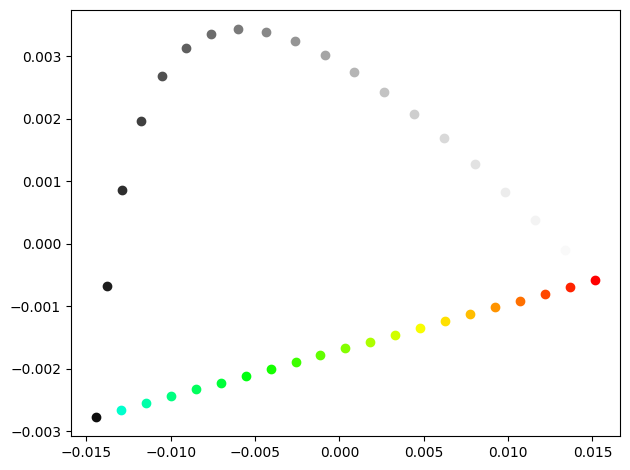

In [ ]:
base_point = compute_dmd(observable(simulate_pitchfork(mu=0.5, x0=x0, dt=dt, T=T)))[0]

mus = list(
    i * 0.05 - 0.5 for i in range(20)
)  # [-0.5, -.1, -.05, -.02, 0.0, .02, .05, .1, .2, .3, 0.5]
dmds = [
    Matrices.align_matrices(
        compute_dmd(observable(simulate_pitchfork(mu=mu, x0=x0, dt=dt, T=T)))[0],
        base_point,
    )
    for mu in mus
]

ts = list(x * 0.05 for x in range(20))
geodesic_dmds = [
    Matrices.align_matrices(x, base_point)
    for x in dmd_space.metric.geodesic(dmds[0], dmds[-1])(ts)
]

dmd_mds = MDS(dmd_space)
dmds_in_2d = dmd_mds.fit(
    list(dmds) + list(geodesic_dmds)
).embedding_  # dmds_in_2d = dmds_in_2d * 10

labs = [str(mu) + "mu" for mu in mus] + [
    str(t) for t in ts
]  # + [str(t)+"crit" for t in ts]
cmap = plt.get_cmap("hsv")
muscmap = plt.get_cmap("Greys")
fig, axes = plt.subplots(1, 1)

for mat in range(dmds_in_2d.shape[0]):
    if mat < len(mus):  # dmds_in_2d[mat, 0] > 0:
        axes.scatter(
            dmds_in_2d[mat, 0],
            dmds_in_2d[mat, 1],
            c=muscmap(mat / len(mus)),
            label=labs[mat],
        )
    else:
        axes.scatter(
            dmds_in_2d[mat, 0],
            dmds_in_2d[mat, 1],
            c=cmap((mat - len(mus)) / dmds_in_2d.shape[0]),
            label=labs[mat],
        )
# plt.legend()
plt.tight_layout()
plt.show()

## Lorenz

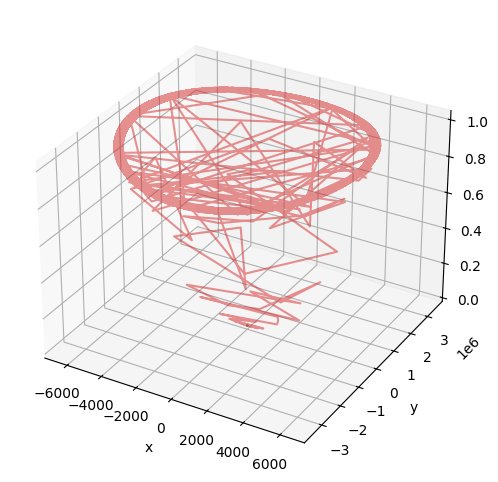

In [ ]:
from scipy.integrate import solve_ivp

# ---------------------------------------------------------
# ODE system in
# xdot = a*(y-x)
# ydot = (c-a)*x-x*z+c*y
# zdot = x*y-b*z
# ---------------------------------------------------------

a = 35
b = 3
# regions are
# 10-16 nice all converge origin, 18-22 are switching butterfly, 26-30
cs = [1, 10, 30, 40]


def hw_system(t, S, a=a, b=b, c=cs[0]):
    x, y, z = S
    fx = a * (y - x)
    fy = (c - a) * x - x * z + c * y
    fz = x * y - b * z
    return [fx, fy, fz]


S0 = [1, 1, 1]
t_span = (0, 100)

# xs = np.linspace(-2, 2, 10)
# ys = np.linspace(-2, 2, 10)
# zs = np.linspace(-2, 2, 10)
initial_points = [S0]  # (1, 1, 1)
# for x in xs:
#     for y in ys:
#         for z in zs:
#             initial_points.append((x, y, z))

# Solve the ODE; 'RK45' is the default method
solutions = []
t = np.linspace(t_span[0], t_span[1], 1000)
# for initial_point in initial_points:
for c in cs:
    solution = solve_ivp(
        lambda t, S: hw_system(t, S, c=c), t_span, S0, dense_output=True
    )
    sol = solution.sol(t)

    solutions.append(sol)

# 4. Plot the results
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
for sol in solutions:
    x, y, z = sol[0], sol[1], sol[2]
    ax.plot(x, y, z, alpha=0.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()

In [57]:
solutions

[array([[ 1.00000000e+00, -1.65928161e-01,  2.62167505e-02, ...,
          1.41987282e-06,  1.15660472e-07, -7.44076107e-08],
        [ 1.00000000e+00, -1.95395620e-01,  3.73601178e-02, ...,
          1.53220250e-06,  5.84071986e-07,  3.83703477e-08],
        [ 1.00000000e+00,  7.51269012e-01,  5.56799804e-01, ...,
          3.67103379e-12, -5.15723813e-12, -5.83693679e-12]],
       shape=(3, 1000)),
 array([[ 1.00000000e+00,  4.21109843e-02, -9.33956058e-02, ...,
          8.50961845e-07, -1.27979438e-06,  1.23848168e-08],
        [ 1.00000000e+00, -1.63668750e-01, -4.47437050e-02, ...,
          6.09352651e-07, -8.57422309e-07,  1.93283944e-07],
        [ 1.00000000e+00,  7.61298388e-01,  5.64959366e-01, ...,
         -9.67510430e-12, -9.00199120e-12, -6.84532832e-12]],
       shape=(3, 1000)),
 array([[  1.        ,   7.75133421,  25.12475277, ...,   1.04459973,
         -11.01682524,  -9.88296935],
        [  1.        ,  13.50418271,   1.06722557, ...,  -3.37847037,
         -13.5